In [1]:
import pickle
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA

from plotting.cell_state_plotters import plot_cell_state_2d, plot_cell_state_3d

In [2]:
# full_q

full_q_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))
	
with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_410.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_553.p", "rb") as f: 
   full_q_states.append(pickle.load(f))

# q_filter 

q_filter_states = []

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_116.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_117.p", "rb") as f:
   full_q_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_410.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))

with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_553.p", "rb") as f: 
    q_filter_states.append(pickle.load(f))


In [3]:
mode = "normal"

### Experimentel cell state plots of single basins

May be interesting as a further investigation, if there is time. 

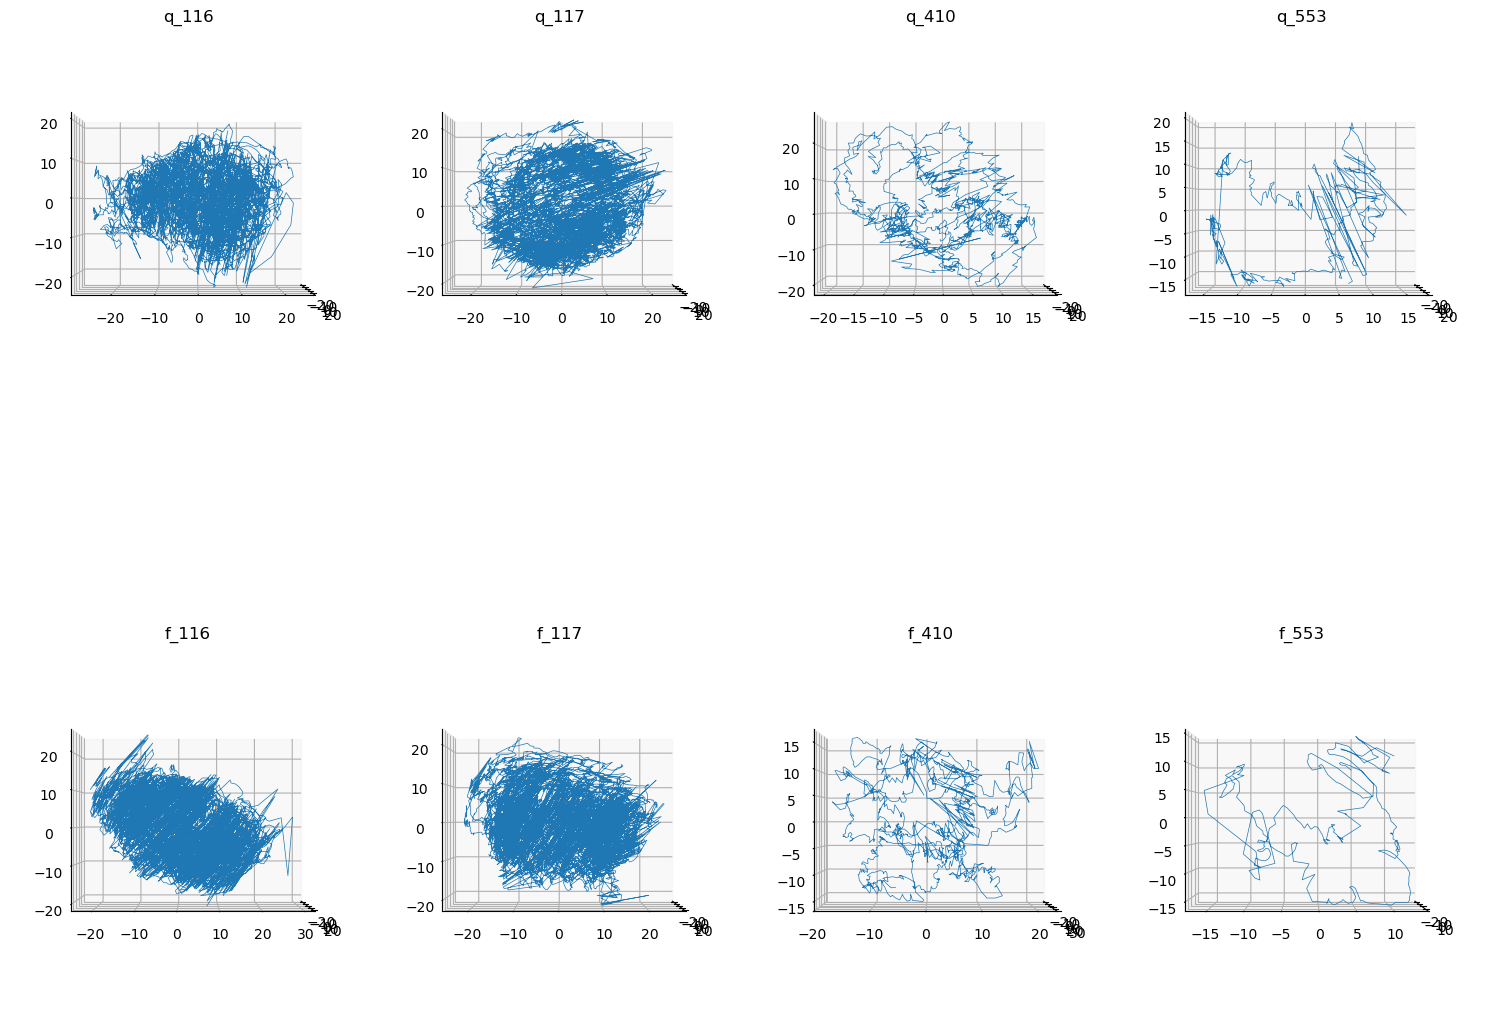

In [4]:
fig, axs = plt.subplots(2,4, figsize=(15,15), subplot_kw={"projection": "3d"})

for ax, array, title in zip(
	axs.ravel(),
	list(map(lambda x: x[mode], full_q_states)) + list(map(lambda x: x[mode], q_filter_states)),
	["q_116", "q_117","q_410", "q_553", "f_116", "f_117", "f_410", "f_553"]):
	
	# Assign every 365 points the same color, to look for seasonal patterns.
	point_colors = np.arange(len(array)) // 365

	plot_cell_state_3d(
		cell_state_array=array,
		ax=ax,
		connect=True,
		ax_view_params={"elev": 0, "azim": 0},
		title=title,
		linewidth=0.5
	)

plt.tight_layout()

### MDS of Average cell state plots of all basins

In [5]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states_means_mds.p", "rb") as f: 
    filter_means_mds = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states_means_mds_10_500.p", "rb") as f: 
    full_means_mds = pickle.load(f)

In [6]:
strata_ids = pd.read_table("/home/wuhlmann/BA/data/processed_data/test_splits/strata_ids_incl_651.txt", header=0, sep=",")
strata_ids.set_index("ID", inplace=True)

In [7]:
lamah_gdf = gpd.read_file("/home/wuhlmann/BA/data/raw_data/2_LamaH-CE_daily/B_basins_intermediate_all/3_shapefiles/Basins_B.shp")
lamah_gdf.set_index("ID", inplace=True)
lamah_gdf["strata"] = strata_ids["0"]
lamah_gdf.sort_index(ascending=True, inplace=True)

In [8]:
show_cluster = True 

In [ ]:
[full_means_mds["2"][m] for m in ["normal", "raw"]] + [filter_means_mds["2"][m] for m in ["normal", "raw"]]

0 basins could not be assined | (array([0, 1, 2]), array([357,   1, 501]))
0 basins could not be assined | (array([0, 1, 2]), array([506, 193, 160]))
0 basins could not be assined | (array([0, 1, 2]), array([483, 201, 175]))
0 basins could not be assined | (array([0, 1, 2]), array([494, 229, 136]))


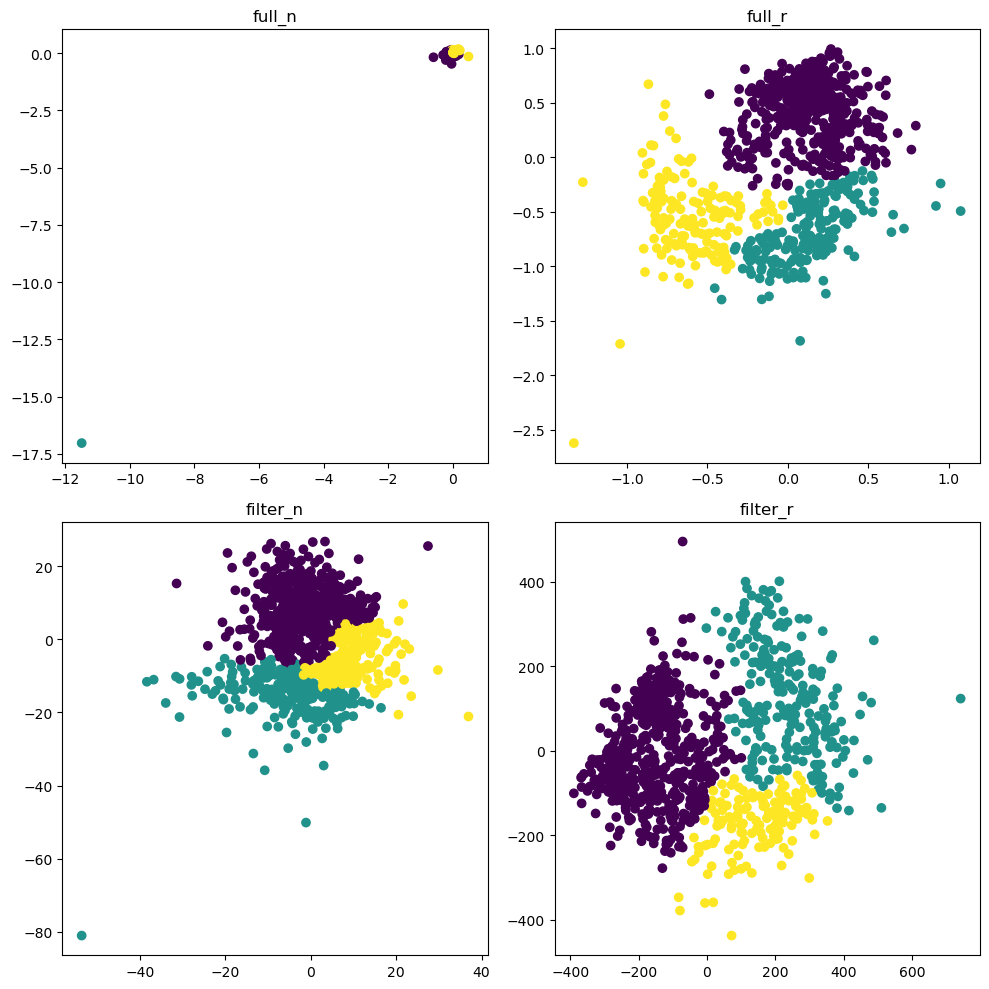

In [9]:
k_means = KMeans(3, random_state=1, max_iter=10)
agglo = AgglomerativeClustering(3, linkage="ward")

fig, axs = plt.subplots(2,2, figsize=(10,10))

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["2"][m] for m in ["normal", "raw"]] + [filter_means_mds["2"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):
	
	if show_cluster:
		cluster = agglo.fit_predict(array)
		#cluster = k_means.fit_predict(array)

		print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")

		lamah_gdf[f"agglo_{title}"] = cluster		
		plot_cell_state_2d(array[cluster!=-1], ax=ax, title=title, c=cluster[cluster !=-1])
	else:
		plot_cell_state_2d(array, ax=ax, title=title, c=strata_ids["0"])

plt.tight_layout()

checek whether or not the labels are correct

<Axes: >

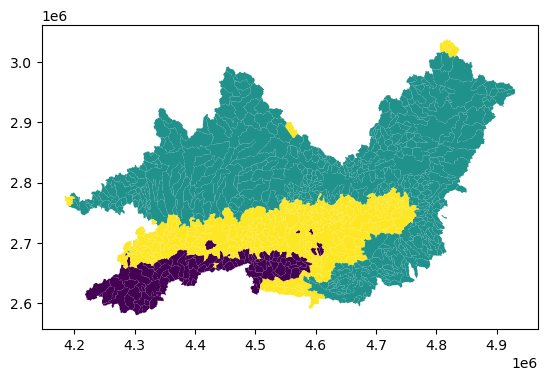

In [10]:
lamah_gdf.plot(column="strata")

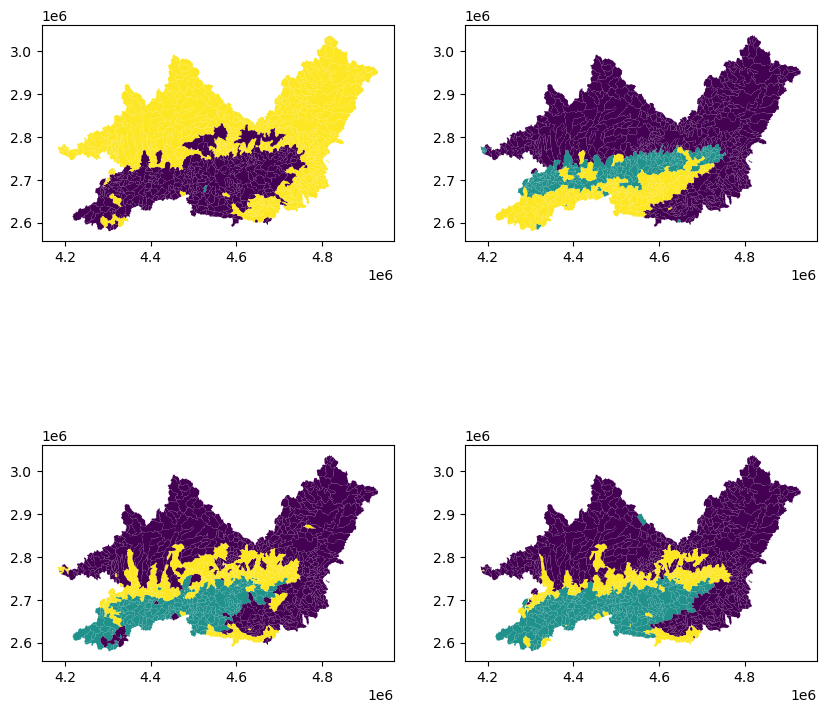

In [11]:
fig, axs = plt.subplots(2,2, figsize=(10,10))

for variant, ax in zip(["full_n","full_r", "filter_n", "filter_r"], axs.ravel()):
    
	lamah_gdf.plot(ax=ax, column=f"agglo_{variant}")

PCA and then k-means clustering, since clusters of stratas appear to be convex. hierch single linkage

we created a regional clustering at the beginning, which the model reproduced in some form. therefore the model represents some regional pattern, which was not explicitly fed into it, but learned from the same + more (dyn) basins characteristics 

0 basins could not be assined | (array([0, 1, 2]), array([344,   1, 514]))
0 basins could not be assined | (array([0, 1, 2]), array([533, 148, 178]))
0 basins could not be assined | (array([0, 1, 2]), array([517, 239, 103]))
0 basins could not be assined | (array([0, 1, 2]), array([360, 211, 288]))


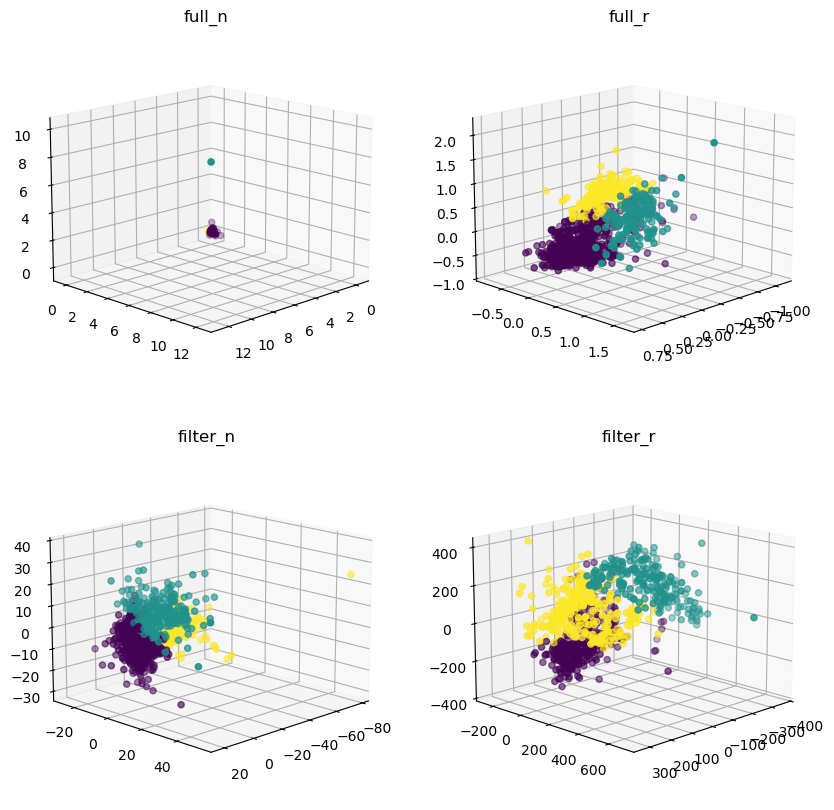

In [12]:
fig, axs = plt.subplots(2,2, figsize=(10,10), subplot_kw={"projection": "3d"})

hdbscan = AgglomerativeClustering(3, linkage="ward")

for ax, array, title in zip(
    axs.ravel(),
	[full_means_mds["3"][m] for m in ["normal", "raw"]] + [filter_means_mds["3"][m] for m in ["normal", "raw"]],
	["full_n","full_r", "filter_n", "filter_r"]):

	if show_cluster: 
		cluster = hdbscan.fit_predict(array)

		print(f"{len(cluster[cluster==-1])} basins could not be assined | {np.unique(cluster, return_counts=True)}")
		lamah_gdf[f"agglo_{title}"] = cluster	
		
		plot_cell_state_3d(array[cluster!=-1], ax=ax, title=title, ax_view_params={"elev": 15, "azim": 45}, c=cluster[cluster !=-1]) 
	else: 
		plot_cell_state_3d(array, ax=ax, title=title, ax_view_params={"elev": 15, "azim": 35}, c=strata_ids) 


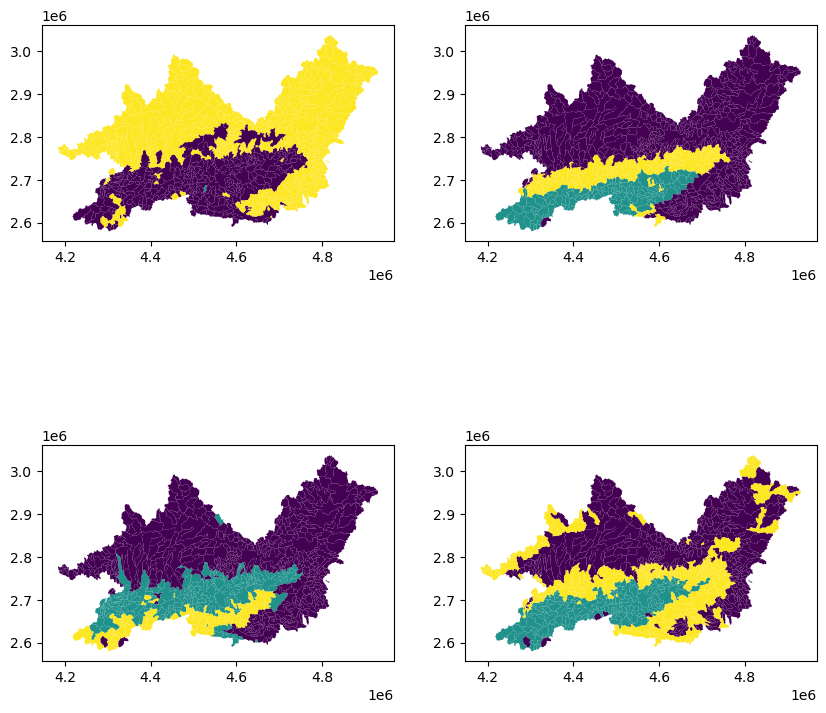

In [13]:
fig, axs = plt.subplots(2,2, figsize=(10,10))

for variant, ax in zip(["full_n","full_r", "filter_n", "filter_r"], axs.ravel()):
    
	lamah_gdf.plot(ax=ax, column=f"agglo_{variant}")

### PCA of average cell states of all basins.

Maybe do the PCA on all cell states of the day of predicion, since they hold more information than the average. 

In [16]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/512_batch_size_2711_095750_cell_states.p", "rb") as f: 
    filtered_raw_cell_states = pickle.load(f)
    
filtered_raw_cell_states = dict(sorted(filtered_raw_cell_states.items(), key=lambda item: int(item[0])))

f_c_means = np.vstack([filtered_raw_cell_states[b]["c_mean"] for b in filtered_raw_cell_states.keys()])

#with open("/home/wuhlmann/BA/data/processed_data/cell_states/full_q_512_3011_185525_cell_states.p", "rb") as f: 
#    full_raw_cell_states = pickle.load(f)
#
#q_c_means = np.vstack([full_raw_cell_states[b]["c_mean"] for b in full_raw_cell_states.keys()])

In [17]:
from sklearn.decomposition import PCA 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_PC_ber_basin = {}

pca_09 = PCA(n_components=0.9, random_state=1277)

for id, cell_state in tqdm(filtered_raw_cell_states.items()):
    
	pca_09.fit(scaler.fit_transform(cell_state["c_last"]))

	num_PC_ber_basin[id] = len(pca_09.explained_variance_)

100%|██████████| 859/859 [04:17<00:00,  3.34it/s]


In [18]:
np.mean(list(num_PC_ber_basin.values()))

27.693830034924332

<Axes: >

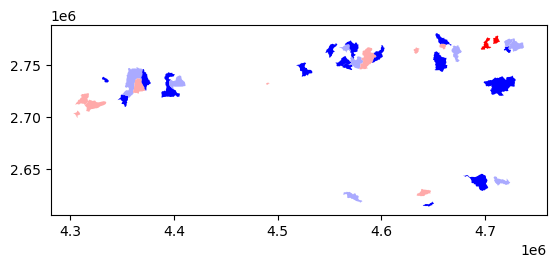

In [24]:
lamah_gdf["numPC"] = list(num_PC_ber_basin.values())
lamah_gdf[lamah_gdf["numPC"] > 35].plot(column="numPC", cmap="bwr")